
    Este código realiza los siguientes pasos:

    1. Carga el conjunto de datos Iris.
    2. Convierte el dataset a un DataFrame de pandas para la descripcion y los primeros valores.
    3. Imprime la descripción de los atributos.
    4. Imprime los 10 primeros valores del dataset.
    5. Imprime los nombres de los primeros 10 atributos (feature names).
    6. Imprime la correspondencia de los valores del target con los nombres de las especies.
    7. Estandariza los datos.
    8. Aplica PCA para reducir la dimensionalidad a 2 componentes principales.
    9. Genera un gráfico de la varianza explicada por cada componente.
    10. Genera un gráfico de los loadings.
    11. Genera un biplot con leyenda.
    12. Imprime la varianza explicada por cada componente principal.
    
Descripción de los atributos del dataset Iris:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.0

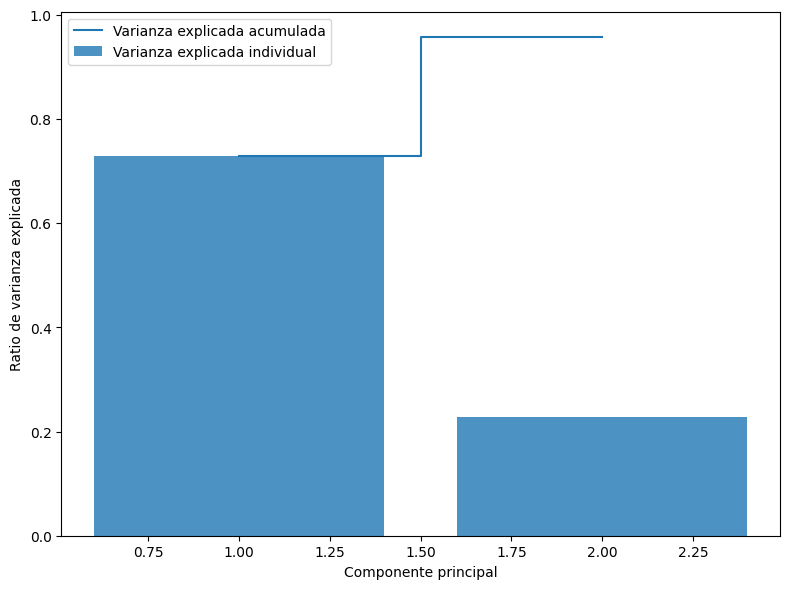

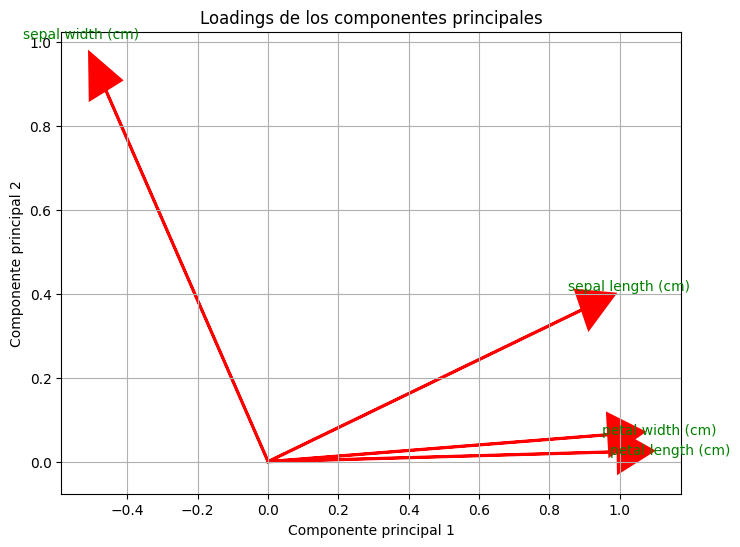

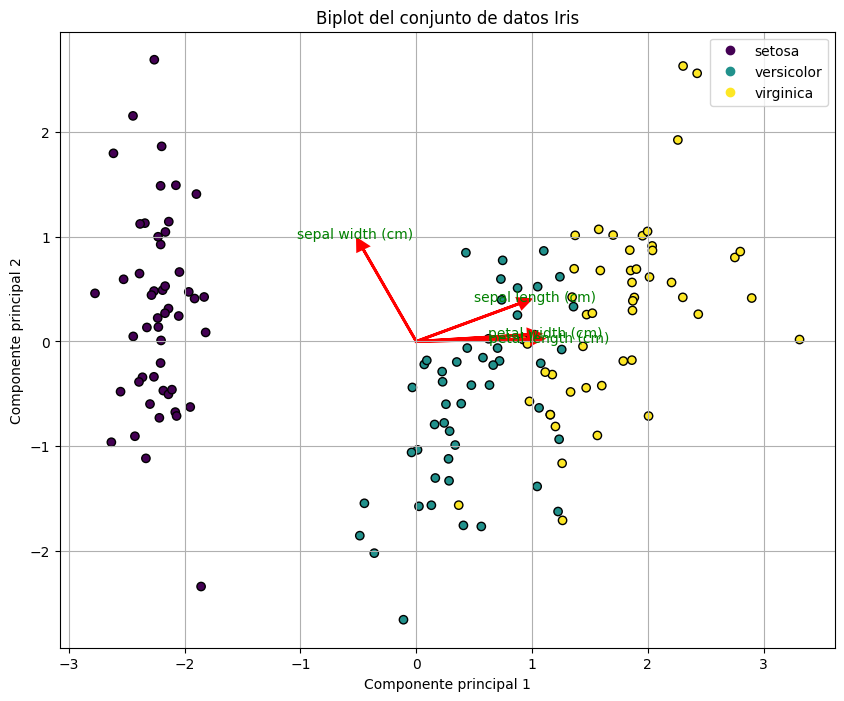

Varianza explicada por componente: [0.72962445 0.22850762]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Cargar el conjunto de datos Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convertir a DataFrame para obtener la descripción y los primeros valores
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])


# Imprimir información general

print(
    """
    Este código realiza los siguientes pasos:

    1. Carga el conjunto de datos Iris.
    2. Convierte el dataset a un DataFrame de pandas para la descripcion y los primeros valores.
    3. Imprime la descripción de los atributos.
    4. Imprime los 10 primeros valores del dataset.
    5. Imprime los nombres de los primeros 10 atributos (feature names).
    6. Imprime la correspondencia de los valores del target con los nombres de las especies.
    7. Estandariza los datos.
    8. Aplica PCA para reducir la dimensionalidad a 2 componentes principales.
    9. Genera un gráfico de la varianza explicada por cada componente.
    10. Genera un gráfico de los loadings.
    11. Genera un biplot con leyenda.
    12. Imprime la varianza explicada por cada componente principal.
    """
)


# Imprimir descripción de los atributos
print("Descripción de los atributos del dataset Iris:")
print(iris_df.describe())

# Imprimir los 10 primeros valores del dataframe
print("\nLos 10 primeros valores del dataset Iris:")
print(iris_df.head(10))

# Imprimir los nombres de los primeros 10 atributos (feature names)
print("\nNombres de los primeros 10 atributos (feature names):")
print(feature_names[:10])

# Imprimir la correspondencia de los valores del target con los nombres de las especies
print("\nCorrespondencia de los valores del target con los nombres de las especies:")
print("Target 0: {}".format(target_names[0]))
print("Target 1: {}".format(target_names[1]))
print("Target 2: {}".format(target_names[2]))

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_

# Gráfico de varianza explicada
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.8, align='center', label='Varianza explicada individual')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Varianza explicada acumulada')
plt.ylabel('Ratio de varianza explicada')
plt.xlabel('Componente principal')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Gráfico de loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(8, 6))
for i in range(loadings.shape[0]):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.1, head_length=0.1, linewidth=2, color='red')
    plt.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, feature_names[i], color='green', ha='center', va='center')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Loadings de los componentes principales')
plt.grid()
plt.show()

# Biplot con leyenda
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k')

for i in range(loadings.shape[0]):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.1, head_length=0.1, linewidth=2, color='red')
    plt.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, feature_names[i], color='green', ha='center', va='center')

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Biplot del conjunto de datos Iris')
plt.grid()

# Agregar leyenda
legend_elements = scatter.legend_elements()
plt.legend(legend_elements[0], target_names)

plt.show()

print('Varianza explicada por componente: {}'.format(explained_variance))

